In [121]:
import triton
import torch
import numpy as np
import os
import pandas as pd
from torch import nn, Tensor, autograd

from triton_gated_mlp.gated_mlp import FusedGatedMLP, EagerGatedMLP
from triton_gated_mlp.utils import get_device


In [122]:
os.environ["TRITON_PRINT_AUTOTUNING"] = "1"

DTYPE = torch.float32

In [123]:
import triton
import triton.language as tl
import torch
from torch import Tensor
import math

def is_hopper():
    return torch.cuda.get_device_capability()[0] == 9

def cdiv(num: int, den: int) -> int:
    return math.ceil(num / den)


def validate_dimensions(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    b_up: Tensor | None,
    WT_gp: Tensor,  # this one is transposed
    b_gp: Tensor | None,
) -> None:
    assert x.ndim <= 2, f"input tensor must have ndims <=2, got {x.ndim}"
    assert WT_up.shape[1] == x.shape[1], "dimension mismatch in WT_up or x"
    assert WT_gp.shape == WT_up.shape, "dimension mismatch in WT_up or WT_gp"

    if b_up is not None:
        assert b_up.shape[0] == WT_up.shape[0], "dimension mismatch in b_up"

    if b_gp is not None:
        assert b_gp.shape[0] == WT_up.shape[0], "dimension mismatch in b_gp"


def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[: old_dims[0], : old_dims[1]] = t
    return new_t


def get_num_streaming_multiprocessors() -> int:
    return (
        2  # dummy value for dev/debugging
        if not torch.cuda.is_available()
        else torch.cuda.get_device_properties("cuda:0").multi_processor_count
    )


@triton.jit()
def map_pid_m_n(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2):
    if optimize_L2:
        pid_m, pid_n = map_pid_m_n_L2_optim(
            pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M
        )
    else:
        n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
        pid_m = pid // n_programs_n
        pid_n = pid % n_programs_n
    return (pid_m, pid_n)


@triton.jit()
def map_pid_m_n_L2_optim(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M):

    num_blocks_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_blocks_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_in_group = GROUP_SIZE_M * num_blocks_n

    group_size_m = GROUP_SIZE_M
    offset_m = pid // num_programs_in_group
    group_size_m = min(GROUP_SIZE_M, num_blocks_m - offset_m * GROUP_SIZE_M)

    pid_m = ((pid % num_programs_in_group) % group_size_m) + offset_m * GROUP_SIZE_M
    pid_n = (pid % num_programs_in_group) // group_size_m

    return (pid_m, pid_n)


@triton.jit()
def _act_fwd(x, act_name: tl.constexpr):
    if act_name == "no_act":
        return x
    elif act_name == "silu":
        return _silu_fwd(x)
    else:
        raise NotImplementedError()


@triton.jit()
def _act_bwd(x, act_name: tl.constexpr):
    if act_name == "no_act":
        return x
    elif act_name == "silu":
        return _silu_bwd(x)
    else:
        raise NotImplementedError()


# -------------------- activations / fwd --------------------


@triton.jit()
def _compute_sigma(x):
    return 1 / (1 + tl.exp(-x))


@triton.jit()
def _silu_fwd(x):
    return x * _compute_sigma(x)


# -------------------- activations / bwd --------------------


@triton.jit()
def _silu_bwd(x):
    sigma = _compute_sigma(x)
    act_prime = sigma * (1 + x * (1 - sigma))
    return act_prime


In [124]:
import triton
import triton.language as tl
import torch
from typing import Optional
import math
from torch import Tensor

# from .utils import (
#     get_num_streaming_multiprocessors,
#     validate_dimensions,
#     cdiv,
#     map_pid_m_n,
# )
# from .fwd import _act_fwd


def get_smem_limit(device=None):
    if device is None:
        device = torch.cuda.current_device()
    props = torch.cuda.get_device_properties(device)

    # This is the maximum dynamic shared memory per block (bytes)
    return props.shared_memory_per_block



def matmul_tma_persistent_get_configs(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": GS, 
            }, num_stages=s, num_warps=w)  #
        for BM in [32, 64, 128,]  #
        for BN in [64, 128, 256, ]  #
        for BK in [16, 32, 64]  #
        for GS in [2, 4]  #
        for s in ([1, 2, 4])  #
        for w in [4, 8]  #
    ]

def prune_invalid_configs(configs, named_args, **kwargs):
    M = named_args["M"]; N = named_args["N"]; K = named_args["K"]

    # Hopper SMEM per-SM is 228KB physical, but many toolchains effectively cap at 99KB
    # Your error reports 101376 bytes, so use that.
    SMEM_LIMIT = get_smem_limit(torch.device("cuda:0"))

    # infer element size (rough). If you always use fp16/bf16 loads for x/W, set 2.
    # If you sometimes stage fp32, set 4.
    BYTES = 4 if DTYPE == torch.float32 else 2 

    pruned = []
    for cfg in configs:
        BM = cfg.kwargs["BLOCK_SIZE_M"]
        BN = cfg.kwargs["BLOCK_SIZE_N"]
        BK = cfg.kwargs["BLOCK_SIZE_K"]

        # basic "fits problem" (optional)
        if BM > M or BN > N or BK > K:
            continue

        num_stages = getattr(cfg, "num_stages", None)
        if num_stages is None:
            num_stages = 2  # conservative default if you don't set it per-config

        # Conservative estimate: tiles staged simultaneously per stage
        # x + up + gp + op  (you can tune this formula to your kernel’s actual staging)
        smem_per_stage = (
            BM * BK   # x
            + BN * BK # WT_up
            + BN * BK # WT_gp
            + BK * BN # WT_op
        ) * BYTES

        smem_est = smem_per_stage * num_stages

        if smem_est <= SMEM_LIMIT:
            pruned.append(cfg)

    if not pruned:
        pruned = [configs[0]]  # keep something
    return pruned


@triton.autotune(
    configs=matmul_tma_persistent_get_configs(), 
    key=["M", "N", "K"],
    prune_configs_by={'early_config_prune': prune_invalid_configs}
)
@triton.jit()
def _fed_kernel(
    x_ptr,
    WT_up_ptr,
    WT_gp_ptr,
    WT_op_ptr,
    x_out_ptr,
    act_fn: tl.constexpr,
    dropout_p,
    M,
    N,
    K: tl.constexpr,
    NUM_SMS,
    flatten: tl.constexpr,
    warp_specialize: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    num_programs_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_programs = num_programs_m * num_programs_n
    optimize_L2 = True

    ### create tensor_descriptor(s) for all the involved tensors
    x_desc = tl.make_tensor_descriptor(
        x_ptr, shape=[M, K], strides=[K, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )
    WT_up_desc = tl.make_tensor_descriptor(
        WT_up_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )
    WT_gp_desc = tl.make_tensor_descriptor(
        WT_gp_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )
    WT_op_desc = tl.make_tensor_descriptor(
        WT_op_ptr,
        shape=[K, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_K, BLOCK_SIZE_N],
    )
    x_out_desc = tl.make_tensor_descriptor(
        x_out_ptr,
        shape=[M, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K],
    )

    ### persistent matmul: use the same kernel to compute several tiles of x_out
    for pid_ in tl.range(pid, num_programs, NUM_SMS, flatten=flatten, warp_specialize=warp_specialize):
        ### map pid to pid_m, pid_n
        pid_m, pid_n = map_pid_m_n(
            pid_, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2
        )

        offset_m = pid_m * BLOCK_SIZE_M
        offset_n = pid_n * BLOCK_SIZE_N

        # print(pid, pid_, pid_m, pid_n, offset_m, offset_n)

        ### compute tile_p = (tile_x @ tile_WT_up) * act(tile_x @ tile_WT_gp)
        tile_up = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        tile_gp = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        for offset_k in tl.range(0, K, BLOCK_SIZE_K):
            tile_x = x_desc.load(offsets=[offset_m, offset_k])
            tile_WT_up = WT_up_desc.load(offsets=[offset_n, offset_k])
            tile_gp_up = WT_gp_desc.load(offsets=[offset_n, offset_k])

            tile_up = tl.dot(tile_x, tile_WT_up.T, acc=tile_up)
            tile_gp = tl.dot(tile_x, tile_gp_up.T, acc=tile_gp)

        tile_prod = tile_up * _act_fwd(tile_gp, act_fn)
        # tile_prod = tile_prod.to(tl.float16)
        
        # acc = x_out_desc.load(offsets=[offset_m, 0])
        # WT_op = WT_op_desc.load(offsets=[0, offset_n]).to(tl.float32)
        # acc = tl.dot(tile_prod, WT_op.T, acc=acc)
        # x_out_desc.store(offsets=[offset_m, 0], value=acc)

        ### compute tile_o = tile_prod @ WT_op.T
        for offset_k in tl.range(0, K, BLOCK_SIZE_K):
            WT_op = WT_op_desc.load(offsets=[offset_k, offset_n])#.to(tl.float32)
            acc = x_out_desc.load(offsets=[offset_m, offset_k]).to(tl.float32)

            acc = tl.dot(tile_prod, WT_op.T, acc=acc)

            x_out_desc.store(offsets=[offset_m, offset_k], value=acc.to(tl.float16))


@torch.no_grad()
def mlp_hidden_states_fwd(
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    WT_gp: Tensor,  # this one is transposed
    act_fn: str,
    WT_op: Tensor,  # this one is transposed
    b_gp: Tensor | None = None,
    b_op: Tensor | None = None,
    b_up: Tensor | None = None,
    dropout_p: float = 0.0,
    warp_specialize: bool = False, 
) -> Tensor:
    """
    This function computes the follwing operations in a fused fashion:

        self.down_proj(self.dropout(self.act_fn(self.gate_proj(x)) * self.up_proj(x)))

    Wieghts WT_up and WT_gp are kept transposed, and they are transposed back inside the
    triton kernel when doing tl.dot(x, W.T, ...)
    """

    ### validate input dimension
    validate_dimensions(x, WT_up, b_up, WT_gp, b_gp)

    M, K = x.shape
    N, _ = WT_up.shape

    ### triton tensor_descriptor needs tensors to have stride(0) that
    # is a multiple of 16. Check this and pad if needed.
    if K % 16 != 0:
        raise NotImplementedError()
        # a = pad_tensor_16_byte_aligned(a, axis=1)
        # b = pad_tensor_16_byte_aligned(b, axis=0)

    if N % 16 != 0:
        raise NotImplementedError()
        # b = pad_tensor_16_byte_aligned(b, axis=1)
        # old_N = N

    ### Create the grid: we are using tensor_descriptor in a persistent
    # implementation (one kernel may execute more programs of the grid,
    # not just a single one).
    # def get_dummy_META():
    #     return {
    #         "BLOCK_SIZE_M": 128,
    #         "BLOCK_SIZE_N": 128,
    #         "BLOCK_SIZE_K": 128,
    #         "GROUP_SIZE_M": 1,
    #     }

    # META = get_dummy_META()
    NUM_SMS = get_num_streaming_multiprocessors()
    # NUM_SMS = 2
    # grid = (
    #     min((NUM_SMS, cdiv(K, META["BLOCK_SIZE_M"]) * cdiv(N, META["BLOCK_SIZE_N"]))),
    # )
    grid = lambda META: (min(
        (NUM_SMS, cdiv(K, META["BLOCK_SIZE_M"]) * cdiv(N, META["BLOCK_SIZE_N"]))
    ),)
    flatten = False if (warp_specialize and is_hopper()) else True


    ### custom allocation function
    def allocator(size, stream: int, allignment: Optional[int]):
        return torch.empty(size, device=x.device, dtype=torch.int8)

    triton.set_allocator(allocator)

    ###
    # x_out = torch.zeros_like(x, dtype=torch.float32, device=x.device)
    x_out = torch.zeros_like(x, dtype=x.dtype, device=x.device)

    with torch.cuda.device(x.device):
        _fed_kernel[grid](
            x,
            WT_up,
            WT_gp,
            WT_op,
            x_out,
            act_fn,
            dropout_p,
            M,
            N,
            K,
            NUM_SMS,
            flatten, 
            warp_specialize,
            # META["BLOCK_SIZE_M"],
            # META["BLOCK_SIZE_N"],
            # META["BLOCK_SIZE_K"],
            # META["GROUP_SIZE_M"],
        )

    return x_out.to(x.dtype) if x_out.dtype != x.dtype else x_out


In [125]:
class GatedMLP(nn.Module):
    def __init__(
        self,
        hidden_size: int = 256,
        intermediate_size: int = 512,
        bias: bool = False,
        hidden_act: str = "silu",
        dropout_p: float = 0.0,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
        self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=bias)
        self.act = nn.SiLU()
        self.act_fn = hidden_act
        # self.dropout = nn.Dropout(dropout_p)

    def forward(self, x, provider = "torch"):
        shapes = x.shape
        if len(shapes) > 2:
            x = x.view(-1, shapes[-1])
        match provider:
            case "torch":
                hidden_states = self.act(self.gate_proj(x)) * self.up_proj(x)
                down_proj = self.down_proj(hidden_states)
                return down_proj.view(shapes) if len(shapes) > 2 else down_proj
            case "torch_functional":
                act = torch.nn.functional.silu
                xp = (x @ self.up_proj.weight.data.T) * act(x @ self.gate_proj.weight.data.T)
                return xp @ self.down_proj.weight.data.T
            case 'triton':
                return mlp_hidden_states_fwd(
                    x=x, 
                    WT_up=self.up_proj.weight.data,
                    WT_gp=self.gate_proj.weight.data,
                    act_fn='silu',
                    WT_op=self.down_proj.weight.data,
                )
'''
    x: Tensor,
    WT_up: Tensor,  # this one is transposed
    WT_gp: Tensor,  # this one is transposed
    act_fn: str,
    WT_op: Tensor,  # this one is transposed
    b_gp: Tensor | None = None,
    b_op: Tensor | None = None,
    b_up: Tensor | None = None,
    dropout_p: float = 0.0,
'''

'\n    x: Tensor,\n    WT_up: Tensor,  # this one is transposed\n    WT_gp: Tensor,  # this one is transposed\n    act_fn: str,\n    WT_op: Tensor,  # this one is transposed\n    b_gp: Tensor | None = None,\n    b_op: Tensor | None = None,\n    b_up: Tensor | None = None,\n    dropout_p: float = 0.0,\n'

provider='torch', DTYPE=torch.float32, M=32, N=32, K=32
provider='torch_functional', DTYPE=torch.float32, M=32, N=32, K=32
provider='triton', DTYPE=torch.float32, M=32, N=32, K=32
Autotuning kernel _fed_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 2, num_warps: 4, num_ctas: 1, num_stages: 1, maxnreg: None
Triton autotuning for function _fed_kernel,
with key as (32, 32, 32, 'torch.float32', 'torch.float32', 'torch.float32', 'torch.float32', 'torch.float32'),
finished after 0.44s,
best config selected: BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 2, num_warps: 4, num_ctas: 1, num_stages: 1, maxnreg: None;
provider='torch', DTYPE=torch.float32, M=64, N=64, K=64
provider='torch_functional', DTYPE=torch.float32, M=64, N=64, K=64
provider='triton', DTYPE=torch.float32, M=64, N=64, K=64
Autotuning kernel _fed_kernel with config BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 2, num_warps: 4, num_ctas: 1, num_

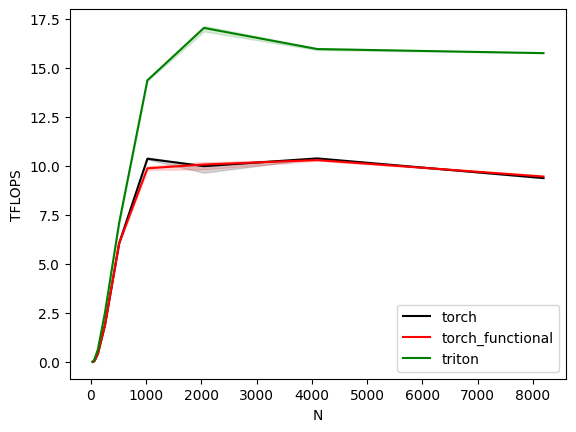

gated-mlp-performance:
        N       M       K      torch  torch_functional     triton
0    32.0    32.0    32.0   0.007385          0.007385   0.017455
1    64.0    64.0    64.0   0.052966          0.052966   0.128000
2   128.0   128.0   128.0   0.438857          0.437150   0.646737
3   256.0   256.0   256.0   1.890462          1.893876   2.520615
4   512.0   512.0   512.0   6.049477          6.049477   7.084973
5  1024.0  1024.0  1024.0  10.364836          9.876697  14.364055
6  2048.0  2048.0  2048.0   9.988420         10.072373  17.034147
7  4096.0  4096.0  4096.0  10.382895         10.297377  15.958037
8  8192.0  8192.0  8192.0   9.380389          9.458780  15.750250


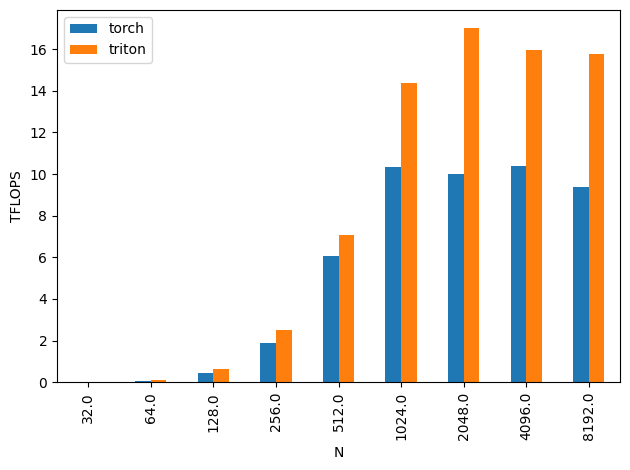

In [126]:
providers = ["torch", 'torch_functional', "triton"]

available_colors = [
    "black",
    "red",
    "green",
    "blue",
    "yellow",
    "cyan",
    "purple",
    "grey",
]
colors = available_colors[: len(providers)]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["N", "M", "K"],  # Argument names to use as an x-axis for the plot
        x_vals=[
            int(2**i) for i in np.arange(5, 14, 1)
        ],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
        line_vals=providers,  # ["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=providers,  # ["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
        styles=[
            (x, "-") for x, _ in zip(colors, providers)
        ],  # ("green", "-"), ("blue", "-")],
        ylabel="TFLOPS",  # Label name for the y-axis
        plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    )
)

def step(mlp, x, provider):
    out = mlp(x, provider)
    # params = (x, mlp.gate_proj.weight, mlp.up_proj.weight, mlp.down_proj.weight)
    # grads = autograd.grad(out, params, torch.rand_like(x).to(x.device))


DEVICE = get_device()

def get_mlp(N, K, DEVICE, DTYPE):
    gmlp_kwargs = {
        "hidden_size": K,
        "intermediate_size": N,
        "dropout_p": 0.0,
        "bias": False,
    }
    return GatedMLP(**gmlp_kwargs).to(DEVICE).to(DTYPE)

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):

    # M *= 4
    # K *= 2

    gmlp = get_mlp(N, K, DEVICE, DTYPE)
    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")

    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    x.requires_grad = True

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: step(gmlp, x, provider), quantiles=quantiles
    )
    perf = lambda ms: 6 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)

df_ops: pd.DataFrame = benchmark.run(
    show_plots=True, print_data=True, return_df=True
)[0]
ax = df_ops.plot(x="N", kind="bar", y=["torch", "triton"], ylabel="TFLOPS")
ax.figure.tight_layout()
ax.figure.savefig("benchmark_tflops.png")